In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import astropy.constants as const

from accomp import class_Planet, class_Star, class_Disk, class_Molecule

In [2]:
st = class_Star.Star(mass=1.2, ref_abund='Asplund2009')

In [3]:
#assume simulated measurements based on AF Lep b
pl_measurements = {}
pl_measurements['S'] = np.random.normal(5.7, 0.8, 10000)
pl_measurements['C'] = np.random.normal(3.5, 0.5, 10000)
CtoO_simulated = np.random.normal(0.8, 0.05, 10000)
pl_measurements['O'] = pl_measurements['C'] / CtoO_simulated #np.random.normal(4.4, 0.6, 10000)

pl_loc = 9. #location in au

In [4]:
mol_dict = class_Molecule.MoleculeDict(st)
mol_dict.set_default_composition()

Putting remaining element fraction for C in refractory
Putting remaining element fraction for O in refractory
Putting remaining element fraction for S in refractory


In [5]:
disk = class_Disk.Disk(st)
disk.set_temp_struct()
solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict, temp=50.)

In [6]:
mol_dict.get_mol_Tcond()

{'Al': 2000.0,
 'Ca': 2000.0,
 'Si': 1600.0,
 'Mg': 1600.0,
 'Fe': 1600.0,
 'Ni': 1600.0,
 'O_refractory': 1600.0,
 'Na': 1100.0,
 'NH4SH': 300.0,
 'C_refactory': 300.0,
 'S_refactory': 300.0,
 'H2O': 170.0,
 'H2S': 90.0,
 'CO2': 70.0,
 'NH3': 70.0,
 'CO': 30.0,
 'N2': 25.0,
 'Ne': 25.0,
 'Ar': 25.0}

In [7]:
#temperature at AF Lep b's location
disk.get_location_temperature(pl_loc)

61.624498319194565

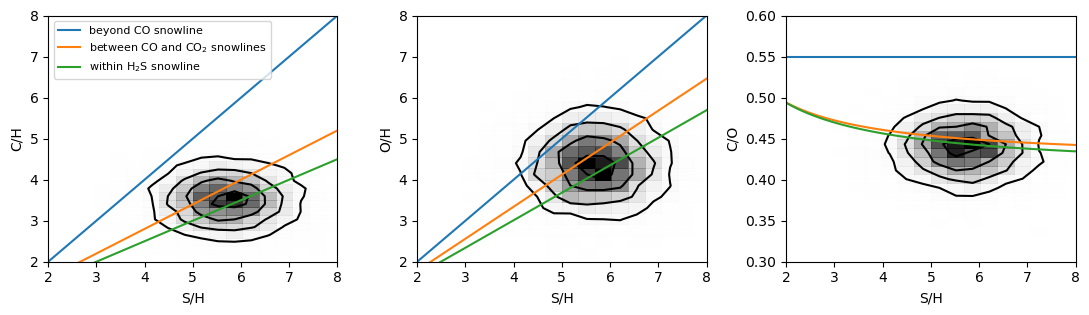

In [8]:
S_to_H_vary = np.logspace(0., 1.)

T_arr = np.array([25., 50., 130.])
lbls_arr = np.array(['beyond CO snowline', 'between CO and CO$_2$ snowlines', 'within H$_2$S snowline'])

# unique_Tcond = np.unique(list(mol_dict.get_mol_Tcond().values()))
# T_arr = 0.5 * (unique_Tcond[1:] + unique_Tcond[:-1])
# T_arr = np.append(min(unique_Tcond) - 5., T_arr)
# T_arr = T_arr[:-3]

fig, axs = plt.subplots(ncols=3, figsize=(11, 3.25), sharex=True)

corner.hist2d(pl_measurements['S'], pl_measurements['C'], ax=axs[0], plot_datapoints=False)
corner.hist2d(pl_measurements['S'], pl_measurements['O'], ax=axs[1], plot_datapoints=False)
corner.hist2d(pl_measurements['S'], pl_measurements['C'] / pl_measurements['O'] * st.CtoO, ax=axs[2], plot_datapoints=False)

for t, temp in enumerate(T_arr):
    solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict, temp=temp)
    predicted_comp = disk.assemble_planet(S_to_H_vary, solid_comp, gas_comp)

    axs[0].plot(S_to_H_vary, predicted_comp['C'], label=lbls_arr[t])
    axs[1].plot(S_to_H_vary, predicted_comp['O'])
    axs[2].plot(S_to_H_vary, predicted_comp['C'] / predicted_comp['O'] * st.CtoO)


axs[0].legend(fontsize=8)
axs[0].set_xlim(2, 8)
axs[0].set_ylim(2, 8)
axs[0].set_xlabel('S/H')
axs[0].set_ylabel('C/H')

axs[1].set_ylim(2, 8)
axs[1].set_xlabel('S/H')
axs[1].set_ylabel('O/H')

axs[2].set_ylim(0.3, 0.6)
axs[2].set_xlabel('S/H')
axs[2].set_ylabel('C/O')

fig.tight_layout()
#plt.savefig('formation-composition-links.pdf', bbox_inches='tight')

In [9]:
solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict, temp=60.) #at a temperature comparable to the one expected at the planet's location

In [10]:
solid_comp['S'] #with the assumed composition of disk solids and gas, sulfur is entirely in the solids at 9 au.

1.0

Since S may not be a perfect tracer of refractories and much of the mass fraction of metals is contained in Fe, Mg, and Si, we add 'measurements' of these elemental species to our planet's inventory to get a better estimate of the metal mass of the planet.

If all of S is in solids, then these added enrichments of Fe, Mg, and Si will just be the same as S. If we are in a region of the disk where S is not fully in solids, then we need to account for the < 1 fraction of S in solids while calculating expected enrichment of Fe, Mg, and Si.

In [11]:
simulated_measurements = class_Planet.Planet.simulate_refractory_measurement(pl_measurements, ['Fe', 'Mg', 'Si'], solid_comp)

pl_measurements = simulated_measurements | pl_measurements 

In [12]:
planet = class_Planet.Planet(st, pl_measurements, loc=9.)
planet.set_planet_mass(3.5, 0.5)
planet.get_metal_mass()

In [13]:
planet.__dict__.keys()

dict_keys(['star', 'measured_abund', 'loc', 'species_name', 'abund_dict', 'mass_averaged_enrichment', 'mass_fraction', 'mass', 'metal_mass'])

[44.67826002 53.89979831 63.82037234]


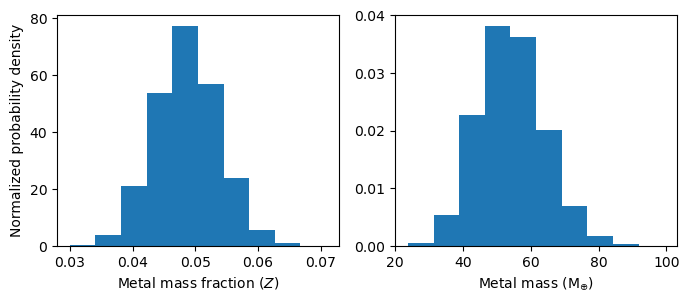

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 3))
axs[0].hist(planet.mass_fraction[2], density=True)
axs[1].hist(planet.metal_mass * const.M_jup.value/const.M_earth.value, density=True)

axs[0].set_ylabel('Normalized probability density')

axs[0].set_xlabel('Metal mass fraction ($Z$)')
axs[1].set_xlabel('Metal mass (M$_{\\oplus}$)')

print(np.percentile(planet.metal_mass * const.M_jup.value/const.M_earth.value, [16, 50, 84]))

#plt.savefig('Metal-mass-constraints.pdf', bbox_inches='tight')

In [15]:
planet.get_metal_mass_breakdown(solid_comp, gas_comp, 'Fe')

For a fraction of samples, the predicted enrichment for element C is
greater than the measured enrichment due to the assumed split for this
element between local solid and gas composition. This is expected
because planet measurements can 'fall' on both sides of the predicted
composition. Use function constrain_elem_frac_in_solids to put
empirical constraints on the split of elements between disk solids and
gas.
For a fraction of samples, the predicted enrichment for element O is
greater than the measured enrichment due to the assumed split for this
element between local solid and gas composition. This is expected
because planet measurements can 'fall' on both sides of the predicted
composition. Use function constrain_elem_frac_in_solids to put
empirical constraints on the split of elements between disk solids and
gas.


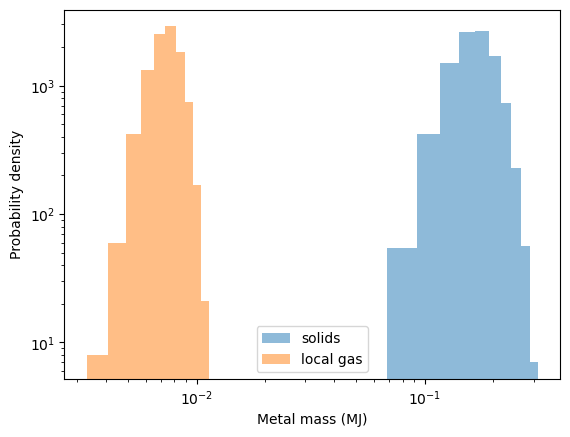

In [16]:
plt.figure()
plt.hist(planet.metal_mass_solids, log=True, alpha=0.5, label='solids')
plt.hist(planet.metal_mass_local_gas, log=True, alpha=0.5, label='local gas')
#plt.hist(planet.metal_mass_excess_metal, alpha=0.5, label='excess metal') #in this case, we do not need excess metals since local material explains the abundance patterns that are observed

plt.xlabel('Metal mass (MJ)')
plt.ylabel('Probability density')
plt.xscale('log')
plt.legend()

#plt.savefig('metal-mass-breakdown.pdf', bbox_inches='tight')

We can also use the measured abundances to place constraints on the fraction of each element that is required to be in solids if the measurements are to be explained by accretion of local solids and gas alone.

[0.55294598 0.72254342 0.93868727]
[0.4077626  0.53492801 0.69399386]


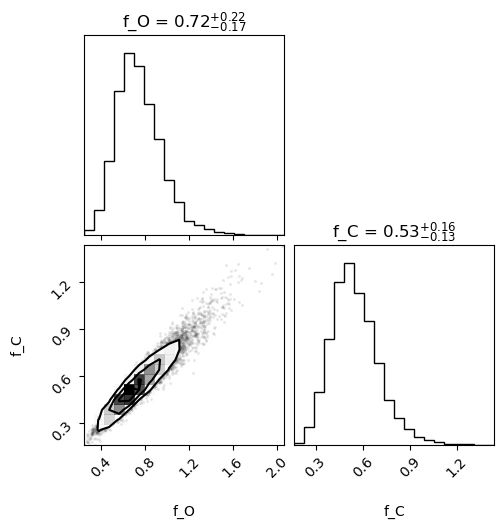

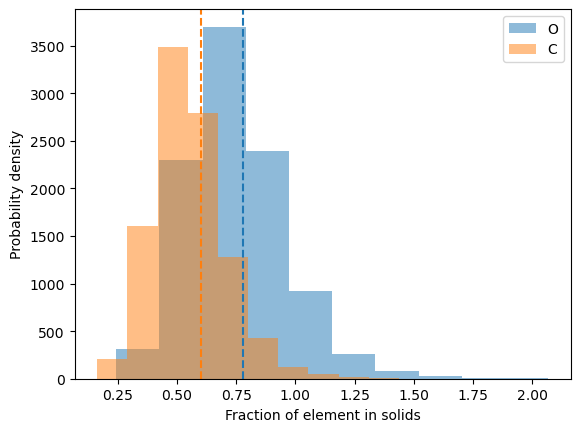

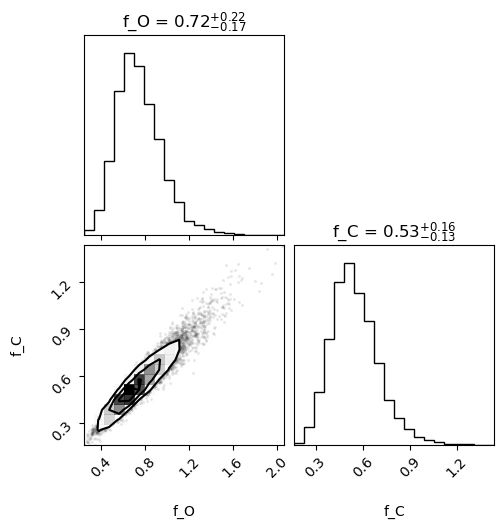

In [17]:
#assuming that O and C come from local solids and gas, let us constrain the fraction of these elements that need to be in solids

f_v = planet.constrain_elem_frac_in_solids('Fe')

print(np.percentile(f_v['O'], [16, 50, 84]))
print(np.percentile(f_v['C'], [16, 50, 84]))

#this is fraction of this element that is in solids
plt.figure()
plt.hist(f_v['O'], alpha=0.5, label='O')
plt.hist(f_v['C'], alpha=0.5, label='C')

plt.axvline(solid_comp['O'], color='C0', ls='--')
plt.axvline(solid_comp['C'], color='C1', ls='--')

plt.ylabel('Probability density')
plt.xlabel('Fraction of element in solids')
plt.legend()

corner.corner(np.vstack((f_v['O'], f_v['C'])).T, labels=['f_O', 'f_C'], show_titles=True)

We can compare accreted metal mass via solids with simple expectations from accretion of pebbles (small mm-cm sized solids) and planetesimals (> km sized bodies).

20.32795907023316


Text(0, 0.5, 'Pebble isolation mass (M$_{\\oplus}$)')

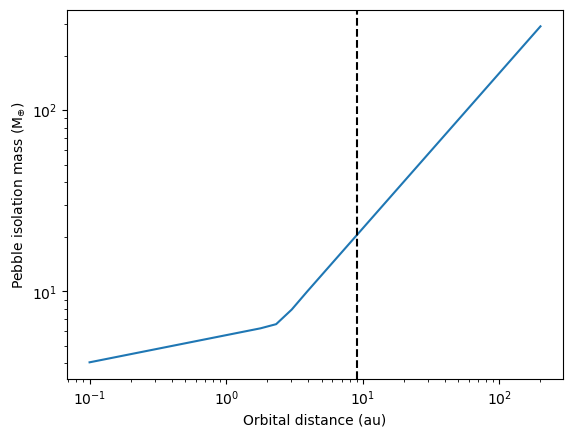

In [18]:
#planet location = 9 au
print(disk.get_pebble_Miso(planet.loc))
plt.loglog(disk.semimajor / const.au.cgs.value, disk.pebble_Miso)
plt.axvline(planet.loc, ls='--', color='k')
plt.xlabel('Orbital distance (au)')
plt.ylabel('Pebble isolation mass (M$_{\\oplus}$)')

array([2.83326157, 3.38656749, 3.97425715])

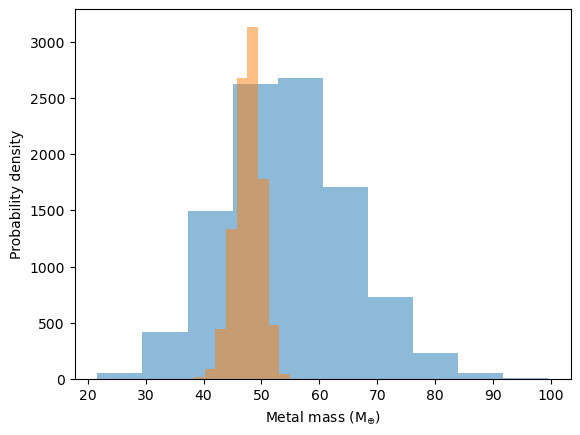

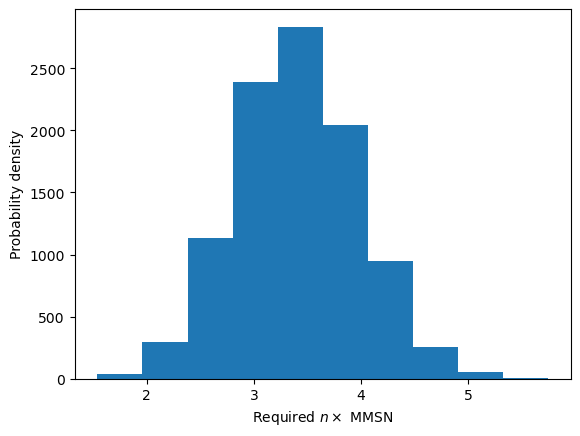

In [ ]:
plt.figure()
plt.hist(planet.metal_mass_solids * const.M_jup.value/const.M_earth.value, alpha=0.5)

n_RHill = 3.5
n_MMSN = 3.
M_pls_fz = disk.get_planetesimal_feeding_zone(planet.loc, planet.mass, n_MMSN, n_RHill)
plt.hist(M_pls_fz, alpha=0.5)
plt.xlabel('Metal mass (M$_{\\oplus}$)')
plt.ylabel('Probability density')


plt.figure()
#We can calculate the required multiple of MMSN that would yield a feeding zone mass that is commensurate with the estimated metal mass accreted via solids
required_n_MMSN = planet.metal_mass_solids * const.M_jup.value/const.M_earth.value / M_pls_fz * n_MMSN
plt.hist(required_n_MMSN)
plt.xlabel('Required $n \\times$ MMSN')
plt.ylabel('Probability density')

np.percentile(required_n_MMSN, [16, 50, 84])

In [20]:
#calculate the Toomre Q of the disk with a specified surface density
Q = disk.get_Toomre_Q(sigma_solids= disk.get_nxMMSN_sigma(disk.semimajor/const.au.cgs.value, n_MMSN))

print(np.interp(np.log10(planet.loc), np.log10(disk.semimajor/const.au.cgs.value), Q))

4.9421707676816435
